# Noise, Variability & Modeling Data

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

**Lecture:** 3

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_1/Notebook_1b_Noise_and_Modeling_Data.ipynb)

## Module Theme

In the previous notebook, we framed learning problems and built the tools to represent data as vectors and matrices. Here we turn to a harder truth:

> Data is not truth. It is a noisy, incomplete snapshot of a process.

This notebook covers where **variability** comes from, and the tools we use to **model** it: covariance (the shape of data) and probability distributions (models of uncertainty).

In [1]:
# This notebook runs as its own kernel, so we re-import the core libraries.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Noise, Variability, and Data-Generating Processes

Data is **not truth**. It is:

- a snapshot,
- from a process,
- observed through measurement systems,
- and usually incomplete.

Sources of variability include:

- measurement noise,
- biological or environmental variability,
- missing data,
- sampling bias,
- changes over time,
- and decisions made before the data were collected.

Two groups can measure the same underlying phenomenon and get different data. That does not necessarily mean one group is wrong. It means there is uncertainty.



In [2]:

np.random.seed(0)

x = np.linspace(0, 1, 40)
true_signal = np.sin(2 * np.pi * x)
noise = np.random.randn(len(x)) * 0.3
observed = true_signal + noise

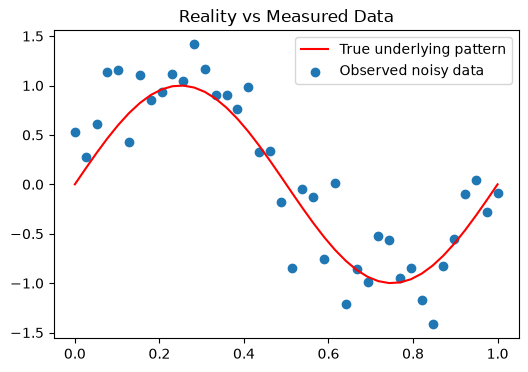

In [3]:
#| code-fold: true
plt.figure(figsize=(6, 4))
plt.plot(x, true_signal, label="True underlying pattern", color="red")
plt.scatter(x, observed, label="Observed noisy data")
plt.legend()
plt.title("Reality vs Measured Data")
plt.show()

## In-Class Case Study: Diagnosing a Learning Problem

We will now practice translating a real-world question into a learning problem.

Each group will receive one case study, such as:

- predicting house prices,
- predicting food delivery time,
- recommending songs,
- predicting bike-share demand,
- detecting defective products,
- predicting wildfire risk.

### Round 1: Frame the learning problem

For your case, answer:

1. What is the real-world question?
2. What is one example or row in the dataset?
3. What features might be available?
4. What is the target or output?
5. What kind of task is this: regression, classification, clustering, recommendation, forecasting, or something else?
6. How would you evaluate whether the model is doing well?
7. What could happen if the model is wrong?

### Round 2: Who or what may be missing?

After you frame the problem, revisit the dataset:

> Who or what might be missing from the data? Whose experience, conditions, examples, or outcomes might not be represented?

This second question is where we begin talking about bias.


### From Case Studies to Modeling Variability

The case studies show that data is shaped by how it was measured and by who or what is missing. To reason about that variability quantitatively, we need tools to describe the **shape** of data and to **model** uncertainty.

We now turn to two such tools:

- **covariance**, which describes how features vary together and gives a data cloud its shape, and
- **probability distributions**, which model the range of values a measurement can take.

(These build on the vectors and matrices from the previous notebook.)

## Covariance: The Shape of Data

So far, we have represented examples as vectors and datasets as matrices.

Now we ask a new question:

> What is the shape of a cloud of data points?

For one variable, variance tells us how spread out the values are.

For two variables, **covariance** tells us whether they vary together.

- Positive covariance: when one variable is high, the other tends to be high.
- Negative covariance: when one variable is high, the other tends to be low.
- Near-zero covariance: the variables do not have a strong linear relationship.

The covariance matrix summarizes the shape of the data cloud.


In [4]:
# Generate a 2D data cloud with correlated features
np.random.seed(4)

mean = np.array([0, 0])
cov = np.array([[3.0, 2.2], [2.2, 2.0]])

X_cloud = np.random.multivariate_normal(mean, cov, size=400)

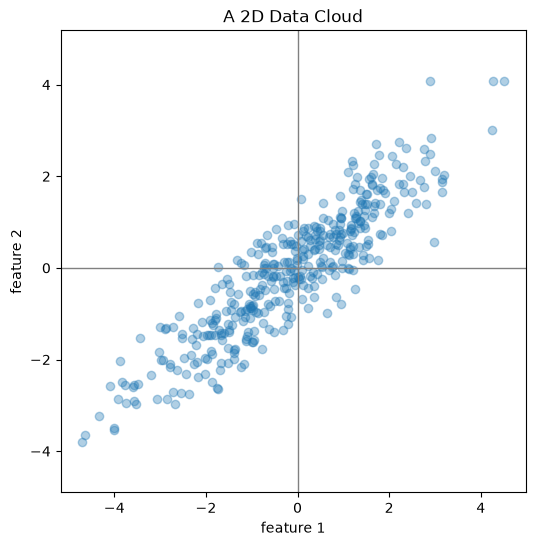

Sample covariance matrix:
[[2.77340155 2.11353135]
 [2.11353135 1.97176927]]


In [5]:
#| code-fold: true
plt.figure(figsize=(6, 6))
plt.scatter(X_cloud[:, 0], X_cloud[:, 1], alpha=0.35)
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.axis("equal")
plt.title("A 2D Data Cloud")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()

print("Sample covariance matrix:")
print(np.cov(X_cloud, rowvar=False))

### Where this goes next

The covariance matrix does more than tell us *whether* two features move together —
it also encodes the **directions** in which the data cloud is stretched. Finding
those directions of greatest variation is the geometric heart of **principal
components analysis (PCA)**, which we develop in **Module 5 (Representation
Learning)**. For now, the takeaway is just that covariance gives a data cloud its
shape.

**Quick discussion.**

1. Looking at the scatter plot, in which direction is the cloud most spread out?
2. What would the cloud look like if the two features had (near) zero covariance?
3. Why might the "direction of greatest variation" be a useful summary of the data?


## Probability Distributions as Models of Data


### Probability Distributions

Real-world data does not give us a single number—it varies.

- Heights differ
- Reaction times differ
- Sensor values fluctuate
- Neural signals vary from trial to trial

This variation is **not random chaos**. It often follows *regular and predictable patterns*.

A **probability distribution** is a way to describe:

- the range of values data can take
- which values are common
- which values are rare

You can think of a distribution as:
> A *model* of uncertainty.

Later in this course we will:

- estimate distributions from data
- reason about uncertainty in predictions
- decide whether two groups differ meaningfully

In particular, **Module 3 (Probability)** treats these distributions rigorously —
each one defined by the *process that generates it*, along with its expectation and
variance. Here we build intuition first.



In [6]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# simulate repeated measurements of something (e.g., a biological measurement)
measurements = rng.normal(loc=50, scale=8, size=500)

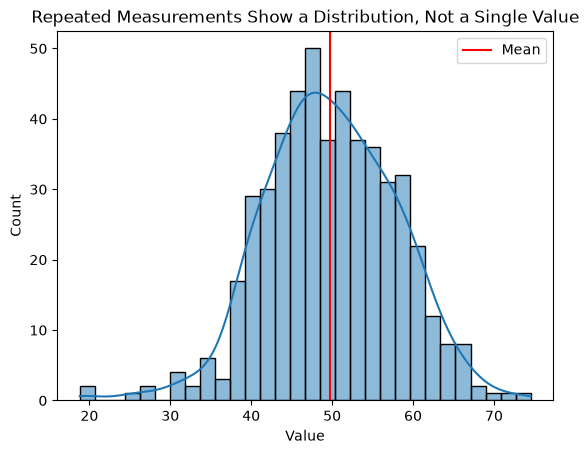

In [7]:
#| code-fold: true
sns.histplot(measurements, bins=30, kde=True)
plt.axvline(np.mean(measurements), color="red", label="Mean")
plt.title("Repeated Measurements Show a Distribution, Not a Single Value")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

### Two Ways to Think About Distributions

#### Probability Density Function (PDF)
- Answers: *“Which values are more likely?”*
- Peaks = common values
- Tails = rare values

This is often what the smooth curve on a histogram shows.

#### Cumulative Distribution Function (CDF)
- Answers: *“How likely is it to be less than this value?”*
- Starts near 0, ends near 1
- Monotonic increasing

We’ll visualize both.


In [8]:
from scipy.stats import norm

x = np.linspace(20, 80, 500)
pdf = norm.pdf(x, loc=50, scale=8)
cdf = norm.cdf(x, loc=50, scale=8)

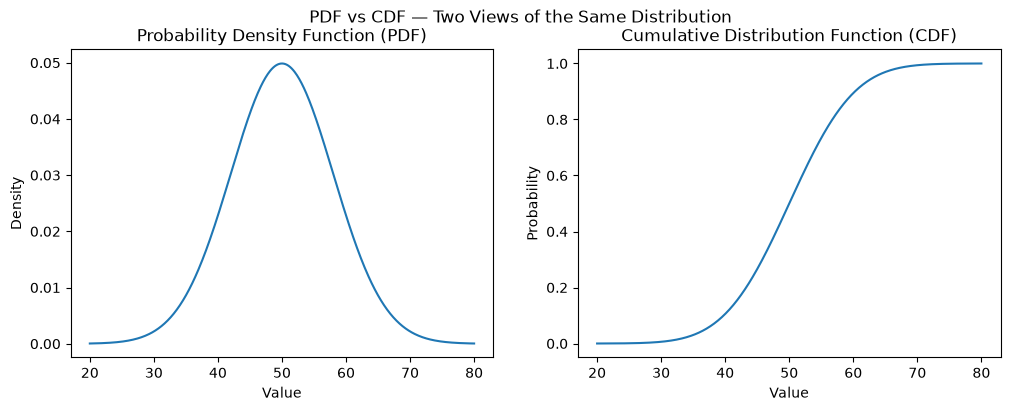

In [9]:
#| code-fold: true
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x, pdf)
ax[0].set_title("Probability Density Function (PDF)")
ax[0].set_ylabel("Density")

ax[1].plot(x, cdf)
ax[1].set_title("Cumulative Distribution Function (CDF)")
ax[1].set_ylabel("Probability")
for a in ax:
    a.set_xlabel("Value")

plt.suptitle("PDF vs CDF — Two Views of the Same Distribution")
plt.show()

The CDF is literally the *running total* of the area under the PDF. The
animation below sweeps a value $x_0$ from left to right: the shaded area under
the PDF up to $x_0$ (left) is exactly the height of the CDF curve at $x_0$
(right).


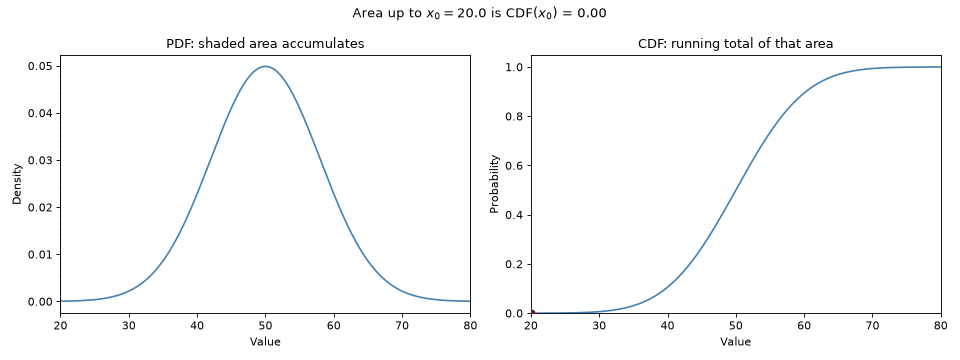

In [10]:
#| code-fold: true
def plot_pdf_cdf_accumulation_gif(
    x, pdf, cdf, n_frames=40, seconds=4.0, hold_seconds=0.8
):
    """
    Left panel: PDF with the area from the start of x up to a sweeping point x0
    shaded in. Right panel: CDF curve with a marker at (x0, CDF(x0)).
    Shows that the CDF is the running cumulative area under the PDF.
    """
    import base64
    import io

    from IPython.display import HTML, display
    from PIL import Image

    idx = np.linspace(0, len(x) - 1, n_frames).astype(int)

    frames = []
    for i in idx:
        x0 = x[i]

        fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

        ax[0].plot(x, pdf, color="steelblue")
        ax[0].fill_between(x[: i + 1], pdf[: i + 1], color="steelblue", alpha=0.4)
        ax[0].axvline(x0, color="crimson", linestyle="--", linewidth=1)
        ax[0].set_title("PDF: shaded area accumulates")
        ax[0].set_ylabel("Density")

        ax[1].plot(x, cdf, color="steelblue")
        ax[1].scatter([x0], [cdf[i]], color="crimson", zorder=5, s=40)
        ax[1].plot([x0, x0], [0, cdf[i]], color="crimson", linestyle="--", linewidth=1)
        ax[1].plot([x[0], x0], [cdf[i], cdf[i]], color="crimson", linestyle="--", linewidth=1)
        ax[1].set_ylim(0, 1.05)
        ax[1].set_title("CDF: running total of that area")
        ax[1].set_ylabel("Probability")

        for a in ax:
            a.set_xlabel("Value")
            a.set_xlim(x[0], x[-1])

        fig.suptitle(f"Area up to $x_0={x0:.1f}$ is CDF($x_0$) = {cdf[i]:.2f}")
        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=80)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

    frame_duration = int(1000 * seconds / n_frames)
    hold_duration = int(1000 * hold_seconds)
    durations = [frame_duration] * n_frames
    durations[0] = hold_duration
    durations[-1] = hold_duration

    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
    )
    gif_buf.seek(0)

    # Quarto's HTML renderer does not pick up embedded image/gif outputs, so we
    # emit an <img> tag with the GIF inlined as a base64 data URI instead.
    gif_b64 = base64.b64encode(gif_buf.getvalue()).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{gif_b64}" alt="PDF to CDF accumulation">'))


plot_pdf_cdf_accumulation_gif(x, pdf, cdf, seconds=8.0, hold_seconds=1.6)

### Not All Distributions Look the Same

Different systems produce different kinds of variability.

Examples:

- **Normal (Gaussian)**:
  - many natural and biological measurements
  - noise around a mean
- **Uniform**:
  - every value equally likely
- **Skewed**:
  - reaction times, income, waiting times
- **Binary / Categorical**:
  - success vs failure (coin flips)
  - class labels

There is no “one true” distribution.
Choosing a distribution is a **modeling assumption**.


In [11]:
# three example distributions
normal_data = rng.normal(0, 1, 2000)
uniform_data = rng.uniform(-3, 3, 2000)
skewed_data = rng.gamma(shape=2, scale=1, size=2000)

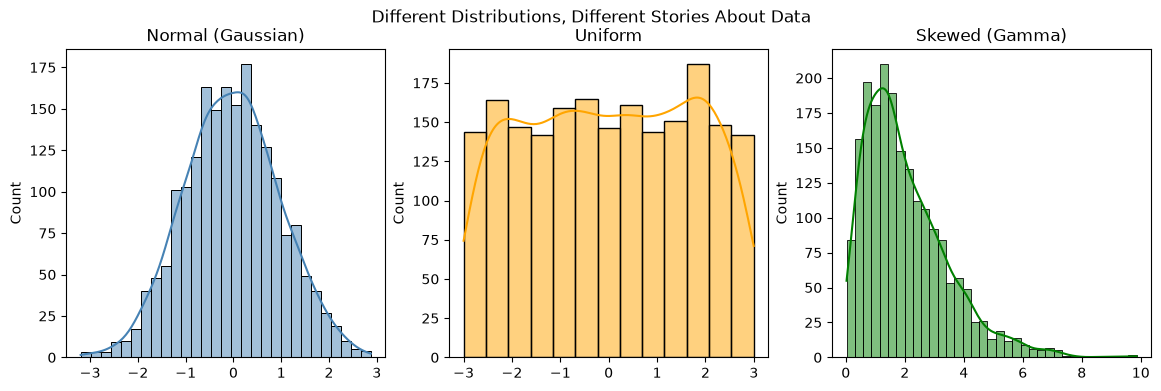

In [12]:
#| code-fold: true
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(normal_data, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Normal (Gaussian)")

sns.histplot(uniform_data, kde=True, ax=ax[1], color="orange")
ax[1].set_title("Uniform")

sns.histplot(skewed_data, kde=True, ax=ax[2], color="green")
ax[2].set_title("Skewed (Gamma)")

plt.suptitle("Different Distributions, Different Stories About Data")
plt.show()

### Computing Statistics


Mean:
$\mu = \mathbb{E}[X]$

Variance:
$\sigma^2 = \mathbb{E}[(X - \mu)^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$


In [13]:
v = np.array([1, 2, 0, 4, 10, 8])

print("max:", np.max(v))
print("sum:", np.sum(v))
print("mean:", np.mean(v))
print("standard deviation:", np.std(v))

max: 10
sum: 25
mean: 4.166666666666667
standard deviation: 3.6704525909242065


### Why This Matters for Modeling (Now and Later)

 1. **Noise and Uncertainty**
Distributions let us talk about uncertainty:

- How confident is a prediction?
- How different is “different”?
- Is a result meaningful, or could it be noise?

 2. **Learning & Loss**
When we fit models (including neural networks),
we are often assuming something about the distribution of errors.

Example:

- Mean Squared Error assumes roughly Gaussian noise.
- Other losses correspond to other assumptions.

 3. **Neural Networks (Coming Soon)**
Neural networks will learn functions **in the presence of noisy, distributed data**.
Understanding distributions helps us:

- interpret outputs
- reason about convergence
- diagnose instability
